In [1]:
# 一、读取数据 & 建模

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

In [5]:
# 读取数据
fact_order = pd.read_excel('/Users/Curry/Desktop/天猫订单数据分析/日化.xlsx', sheet_name='销售订单表')
dim_product = pd.read_excel('/Users/Curry/Desktop/天猫订单数据分析/日化.xlsx', sheet_name='商品信息表')

In [6]:
# 二、数据清洗

In [17]:
# ===== 商品表 =====
dim_product.drop_duplicates(inplace=True)
dim_product.dropna(inplace=True)

# ===== 订单表 =====
fact_order.drop_duplicates(inplace=True)
fact_order.reset_index(drop=True, inplace=True)

# 填充缺失值
fact_order.fillna(method='ffill', inplace=True)
fact_order.fillna(method='bfill', inplace=True)

# 日期处理
fact_order['订单日期'] = pd.to_datetime(fact_order['订单日期'], errors='coerce')

#去掉异常时间
fact_order = fact_order[fact_order['订单日期'] < '2021-01-01']

#数据清洗
fact_order['订购数量'] = fact_order['订购数量'].astype(str).str.replace('个','').astype(int)
fact_order['订购单价'] = fact_order['订购单价'].astype(str).str.replace('元','').astype(float)
fact_order['金额'] = fact_order['金额'].astype(float)

#地域清洗
fact_order['所在省份'] = fact_order['所在省份'].str.replace('自治区｜维吾尔｜回族｜壮族｜省｜市','',regex=True)

/var/folders/w5/2rrg4h2960l1_9mhd7crl3ph0000gp/T/ipykernel_64088/2597172807.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fact_order.fillna(method='ffill', inplace=True)
/var/folders/w5/2rrg4h2960l1_9mhd7crl3ph0000gp/T/ipykernel_64088/2597172807.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fact_order.fillna(method='bfill', inplace=True)


In [18]:
# 三、两表关联

In [23]:
order = pd.merge(fact_order, dim_product, on='商品编号', how='inner')
order.head(3)

,订单编码,订单日期,客户编码,所在区域,所在省份,所在地市,商品编号,订购数量,订购单价,金额,商品名称,商品小类,商品大类,销售单价
0,D31313,2019-05-16,S22796,东区,浙江省,台州市,X091,892,214.0,190888.0,商品91,粉底,彩妆,214
1,D21329,2019-05-14,S11460,东区,安徽省,宿州市,X005,276,185.0,51060.0,商品5,面膜,护肤品,185
2,D22372,2019-08-26,S11101,北区,山西省,忻州市,X078,1450,116.0,168200.0,商品78,口红,彩妆,116


In [24]:
# 四、业务分析

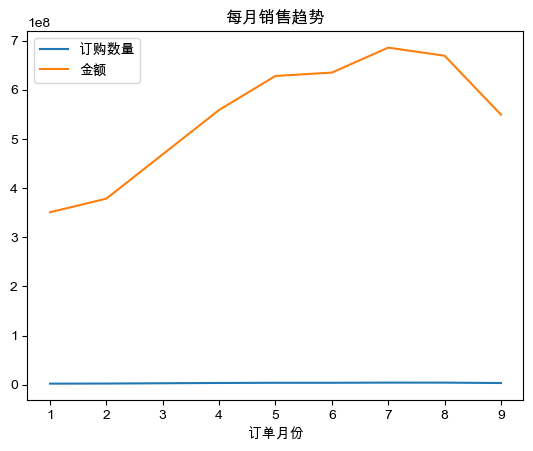

In [36]:
# 4.1时间趋势

fact_order['订单月份'] = fact_order['订单日期'].dt.month

monthly = fact_order.groupby('订单月份').agg({
    '订购数量':'sum',
    '金额':'sum'
})

monthly.plot()
plt.title('每月销售趋势')
plt.show()

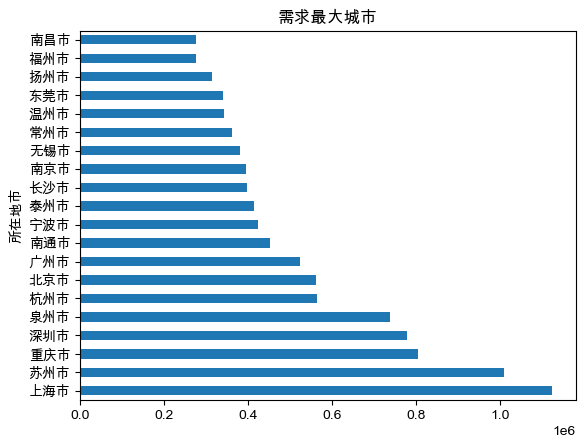

In [35]:
# 4.2城市需求

city_top = fact_order.groupby('所在地市')['订购数量'].sum().sort_values(ascending=False).head(20)

city_top.plot(kind='barh')
plt.title('需求最大城市')
plt.show()

In [38]:
# 4.3商品结构


category = order.groupby(['商品大类','商品小类'])['订购数量'].sum().sort_values(ascending=False)

print(category)

商品大类  商品小类
护肤品   面膜      5451914
      面霜      4567570
      爽肤水     3523687
      眼霜      3350078
      隔离霜     2488124
      防晒霜     2388610
彩妆    口红      2013024
护肤品   洁面乳     1928020
彩妆    粉底      1188621
      睫毛膏      587399
      眼影       296599
      蜜粉        45534
Name: 订购数量, dtype: int64


In [40]:
# 4.4省份分布

province = fact_order.groupby('所在省份')['订购数量'].sum()

province.sort_values(ascending=False).head(3)

所在省份
江苏省    4182163
广东省    2952919
浙江省    2358712
Name: 订购数量, dtype: int64

In [41]:
# 五、RFM

In [44]:
# 5.1 构建RFM

rfm = fact_order.groupby('客户编码').agg({
    '订单日期':'max',
    '订单编码':'count',
    '金额':'sum'
})

rfm.columns = ['最近消费时间','消费频率','消费金额']
rfm

,最近消费时间,消费频率,消费金额
客户编码,,,
S10001,2019-09-15,38,5909783.0
S10011,2019-09-28,31,3887062.0
S10016,2019-07-01,18,2467894.0
S10025,2019-09-20,41,6612251.0
S10057,2019-09-30,38,4763104.0
...,...,...,...
S23299,2019-09-28,25,3732414.0
S23312,2019-09-21,55,6530420.0
S23313,2019-09-21,42,6219869.0


In [46]:
# 5.2 百分位评分

rfm['R'] = rfm['最近消费时间'].rank(pct=True)
rfm['F'] = rfm['消费频率'].rank(pct=True)
rfm['M'] = rfm['消费金额'].rank(pct=True)

In [48]:
# 5.3 加权评分

rfm['score'] = rfm['R']*20 + rfm['F']*30 + rfm['M']*50
rfm['score'] = rfm['score'].round(1)

In [52]:
# 5.4 客户分层

def label(x):
    if x >= 80:
        return '优质客户'
    elif x >= 60:
        return '高价值客户'
    elif x >=40:
        return '潜力客户'
    else:
        return '低价值客户'

rfm['客户类型'] = rfm['score'].apply(label)
rfm['客户类型']

客户编码
S10001      高价值客户
S10011      高价值客户
S10016      低价值客户
S10025      高价值客户
S10057      高价值客户
            ...  
S23299       潜力客户
S23312       优质客户
S23313      高价值客户
S23337      低价值客户
编号S13676    低价值客户
Name: 客户类型, Length: 1084, dtype: object

In [53]:
# 六、机器学习

In [60]:
# 6.1 KMeans

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm_ml = rfm[['R','F','M']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_ml)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head(3)

,最近消费时间,消费频率,消费金额,R,F,M,score,客户类型,Cluster
客户编码,,,,,,,,,
S10001,2019-09-15,38,5909783.0,0.550738,0.73155,0.799815,73.0,高价值客户,0
S10011,2019-09-28,31,3887062.0,0.886993,0.59179,0.517528,61.4,高价值客户,1
S10016,2019-07-01,18,2467894.0,0.039207,0.28321,0.277675,23.2,低价值客户,2


In [57]:
# 6.2 聚类分析

rfm.groupby('Cluster').mean()

TypeError: agg function failed [how->mean,dtype->object]

In [63]:
# 6.3 客户价值预测

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = rfm[['R','F']]
y = rfm['M']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,y_train)

model.feature_importances_

array([0.03630352, 0.96369648])